                                                       MACHINE LEARNING PROJECT
                                                    
                                            LEARNING:SUPERVISED MACHINE LEARNING(CLASSIFICATION)

                                                ✨ PROBLEM STATEMENT ✨

The aim of this project is to develop a supervised machine learning model that analyzes DNA sequence features such as nucleotide composition (A, T, C, G counts), GC/AT content, k-mer frequencies, sequence length characteristics, and mutation indicators to predict an individual's disease risk level (High or Low) and identify the most probable disease category associated with that risk.

The model performs multi-output classification by generating two predictions simultaneously:

->Disease Risk
  >High Risk
  >Low Risk
->Possible Disease Category
  >Low-Risk Diseases:[Common Cold, Seasonal Allergy, Flu, Skin Allergy, Mild Hypertension, Mild Joint Pain, Food Poisoning]
  >High-Risk Diseases:[Cancer, Diabetes, Heart Disease, Stroke, Alzheimer's Disease, Kidney Disease, Lung Disease]

The objective is to assist in the early identification of potential health risks by leveraging genomic sequence patterns and machine learning techniques, enabling faster risk assessment and disease categorization.

                                                              ✨EDA✨

EDA IS EXPLORATORY DATA ANALYSIS IT IS THE PROCESS OF UNDERSTANDING AND EXAMINING THE DATASET BEFORE APPLYING TO ANY MACHINE LEARNING MODEL OR STATISTICS.IT ACTS AS DETECTIVE WORK WHERE WE WORK FOR EXPLORING THE DATA TO FIND PATTERNS,TRENDS AND ANAMOLIES AND RELATIONSHIPS.

# NOTE ::: THIS DATASET IS SYNTHETICALLY GENERATED USING RANDOMIZED VALUES FOR EDUCATIONAL PURPOSES.
# THEREFORE, THE PREDICTIVE RELATIONSHIP BETWEEN FEATURES AND TARGET VARIABLES MAY BE WEAK,
# WHICH CAN RESULT IN LOWER ACCURACY SCORES COMPARED TO REAL-WORLD DATASETS.

In [1]:
#STEP 1 ::: READ THE DATASET AND KNOW THE DATATYPE AND OTHER INFORMATION.
import pandas as pd
df=pd.read_csv("synthetic_dna_disease_dataset.csv")
print(df.info())
print(df.describe())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GC_Content         5000 non-null   float64
 1   AT_Content         5000 non-null   float64
 2   Sequence_Length    5000 non-null   int64  
 3   Num_A              5000 non-null   int64  
 4   Num_T              5000 non-null   int64  
 5   Num_C              5000 non-null   int64  
 6   Num_G              5000 non-null   int64  
 7   kmer_3_freq        5000 non-null   float64
 8   Mutation_Flag      5000 non-null   int64  
 9   Class_Label        5000 non-null   object 
 10  Disease_Risk       5000 non-null   object 
 11  Possible_Diseases  5000 non-null   object 
dtypes: float64(3), int64(6), object(3)
memory usage: 468.9+ KB
None
        GC_Content   AT_Content  Sequence_Length        Num_A        Num_T  \
count  5000.000000  5000.000000      5000.000000  5000.000000  5000.000000

In [2]:
#STEP 2 ::: CHECK IF THERE ARE ANY NULL VALUES,WHAT ARE THE NAME OF THE COLUMNS ALSO FIND HOW MANY DUPILICATED VALUES ARE PRESENT.
print(df.columns)
print(df.isnull().sum())
print(df.duplicated())
print(df.drop_duplicates())

Index(['GC_Content', 'AT_Content', 'Sequence_Length', 'Num_A', 'Num_T',
       'Num_C', 'Num_G', 'kmer_3_freq', 'Mutation_Flag', 'Class_Label',
       'Disease_Risk', 'Possible_Diseases'],
      dtype='object')
GC_Content           0
AT_Content           0
Sequence_Length      0
Num_A                0
Num_T                0
Num_C                0
Num_G                0
kmer_3_freq          0
Mutation_Flag        0
Class_Label          0
Disease_Risk         0
Possible_Diseases    0
dtype: int64
0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool
      GC_Content  AT_Content  Sequence_Length  Num_A  Num_T  Num_C  Num_G  \
0          49.09       50.91              110     23     33     20     34   
1          59.00       41.00              100     21     20     25     34   
2          44.68       55.32               94     23     29     22     20   
3          4

In [3]:
#STEP 3 ::: CHECK EACH COLUMNS UNIQUE VALUES AND ALSO DROP THE COLUMNS WHICH DOESN'T CONTRIBUTE OR CAN BE NOISY AND DOES'T PROVIDE OR HELP TO MAKE PREDICTIONS AND DOES OVERFITTING.
#FIDN THE COLUMN NAME OF EACH DATASET.
print(df.columns)
#FIND THAT IF THE DATASET CONTAINS ANY UNIQUE VALUE OR NOT FOR STANDARDIZATION OF THE DATA.
print(df['Class_Label'].unique())
#DROP THE COLUMNS WHICH ARE NOT USEFUL AND CAN CAUSE OVERFITTING OR MAKE WRONG PREDICITIONS.
# df=df.drop(columns='Sample_ID',axis=1)
print(df.columns)

Index(['GC_Content', 'AT_Content', 'Sequence_Length', 'Num_A', 'Num_T',
       'Num_C', 'Num_G', 'kmer_3_freq', 'Mutation_Flag', 'Class_Label',
       'Disease_Risk', 'Possible_Diseases'],
      dtype='object')
['HUMAN' 'ANIMAL']
Index(['GC_Content', 'AT_Content', 'Sequence_Length', 'Num_A', 'Num_T',
       'Num_C', 'Num_G', 'kmer_3_freq', 'Mutation_Flag', 'Class_Label',
       'Disease_Risk', 'Possible_Diseases'],
      dtype='object')


In [4]:
# STEP 4 ::: CONVERT NON-NUMERICAL COLUMNS INTO NUMERICAL COLUMNS

# CLASS LABEL
print(df['Class_Label'].unique())

df['Class_Label'] = (
    df['Class_Label']
    .str.strip()
    .str.title()
)

df['Class_Label'] = df['Class_Label'].replace({
    'Bacteria': 0,
    'Virus': 1,
    'Human': 2,
    'Plant': 3,
    'Animal': 4
})

# POSSIBLE DISEASES
print(df['Possible_Diseases'].unique())

df['Possible_Diseases'] = df['Possible_Diseases'].str.strip()

df['Possible_Diseases'] = df['Possible_Diseases'].map({
    "['Common Cold', 'Seasonal Allergy', 'Flu', 'Skin Allergy', 'Mild Hypertension', 'Mild Joint Pain', 'Food Poisoning']": 0,

    "['Cancer', 'Diabetes', 'Heart Disease', 'Stroke', \"Alzheimer's\", 'Kidney Disease', 'Lung Disease']": 1
})

# DISEASE RISK
print(df['Disease_Risk'].unique())

df['Disease_Risk'] = (
    df['Disease_Risk']
    .str.strip()
    .str.title()
)

df['Disease_Risk'] = df['Disease_Risk'].map({
    'Low': 0,
    'High': 1
})

# CHECK DATASET
print(df.info())
print(df.head())

sdf = df.copy()

print(sdf.info())

['HUMAN' 'ANIMAL']
["['Common Cold', 'Seasonal Allergy', 'Flu', 'Skin Allergy', 'Mild Hypertension', 'Mild Joint Pain', 'Food Poisoning']"
 '[\'Cancer\', \'Diabetes\', \'Heart Disease\', \'Stroke\', "Alzheimer\'s", \'Kidney Disease\', \'Lung Disease\']']
['LOW' 'HIGH']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GC_Content         5000 non-null   float64
 1   AT_Content         5000 non-null   float64
 2   Sequence_Length    5000 non-null   int64  
 3   Num_A              5000 non-null   int64  
 4   Num_T              5000 non-null   int64  
 5   Num_C              5000 non-null   int64  
 6   Num_G              5000 non-null   int64  
 7   kmer_3_freq        5000 non-null   float64
 8   Mutation_Flag      5000 non-null   int64  
 9   Class_Label        5000 non-null   int64  
 10  Disease_Risk       5000 non-null   int64  

C:\Users\Rudra Chauhan\AppData\Local\Temp\ipykernel_20740\3398570718.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Class_Label'] = df['Class_Label'].replace({


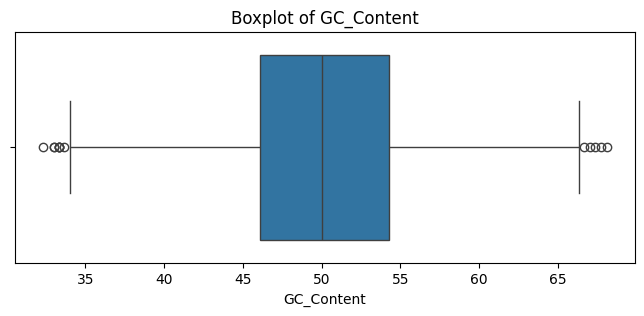

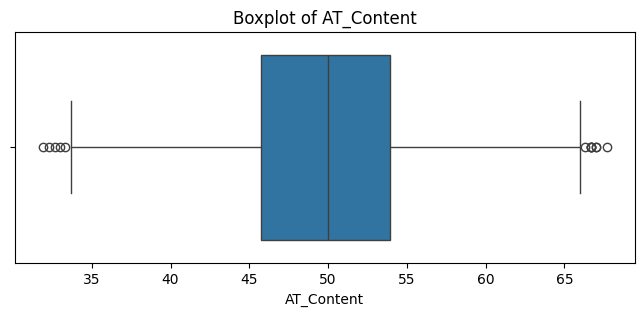

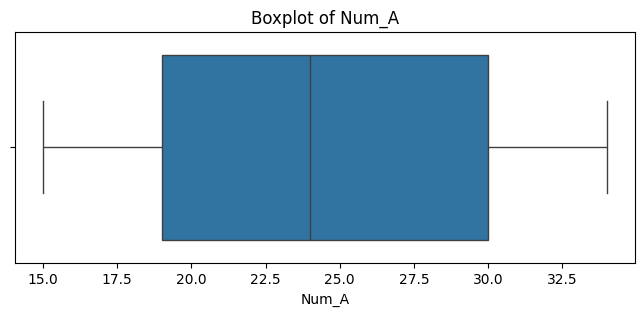

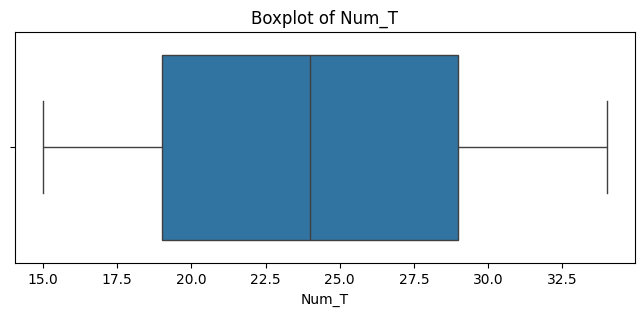

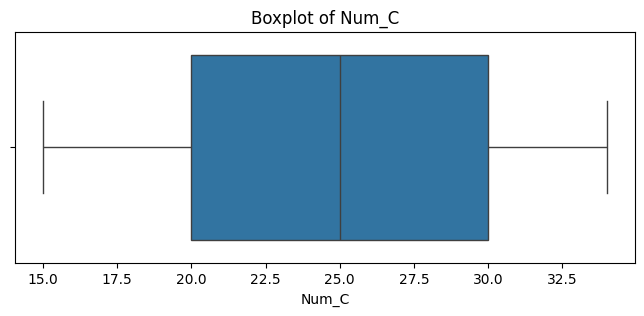

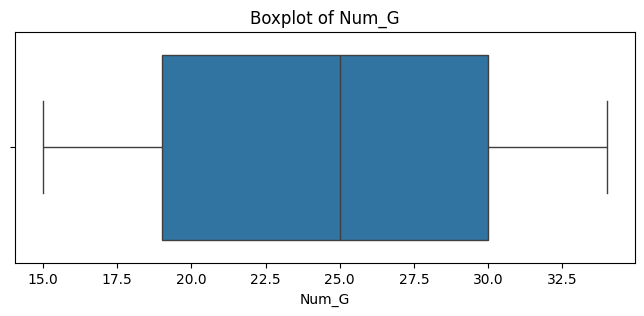

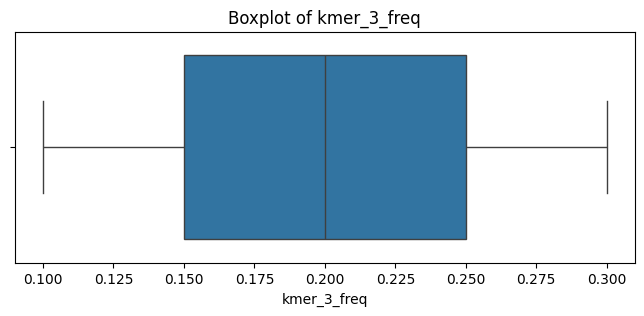

In [6]:
#STEP 5 ::: Check for the outliers in the dataset.
import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = [
    'GC_Content',
    'AT_Content',
    'Num_A',
    'Num_T',
    'Num_C',
    'Num_G',
    'kmer_3_freq'
]

for col in numerical_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

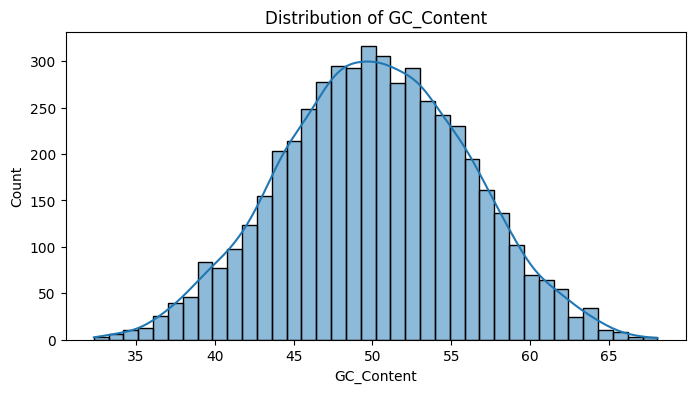

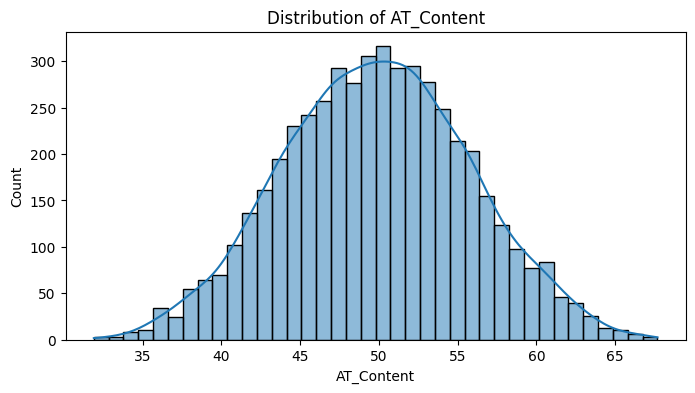

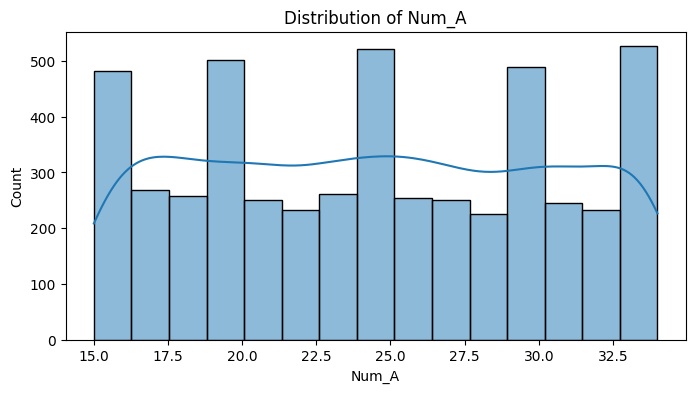

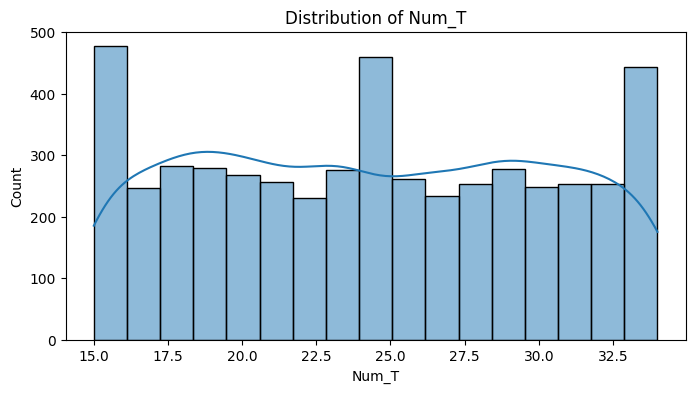

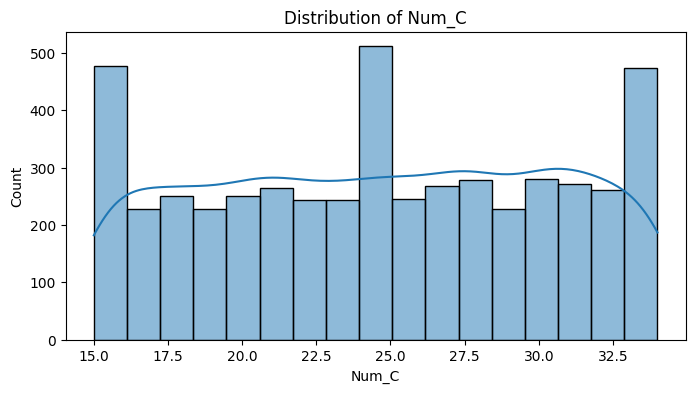

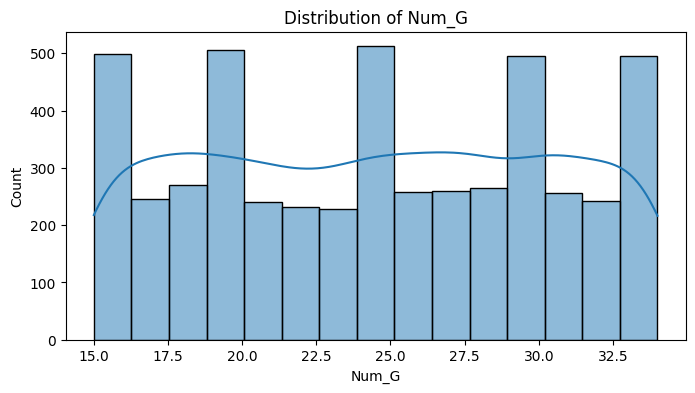

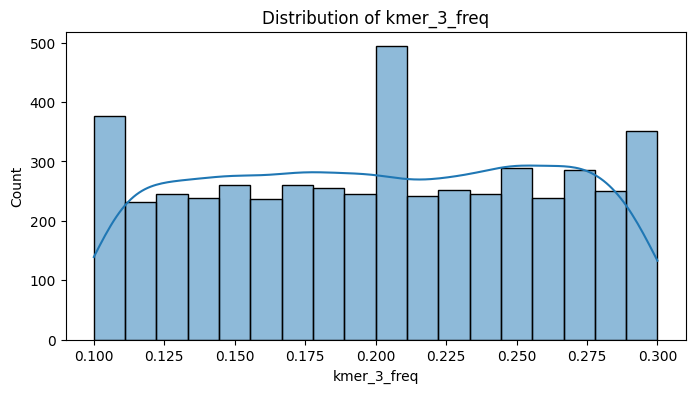

In [7]:
#STEP 6 ::: UNIVARIATE ANALYSIS(STUDY OF ONE FEATURE)
numerical_cols = [
    'GC_Content',
    'AT_Content',
    'Num_A',
    'Num_T',
    'Num_C',
    'Num_G',
    'kmer_3_freq'
]

for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

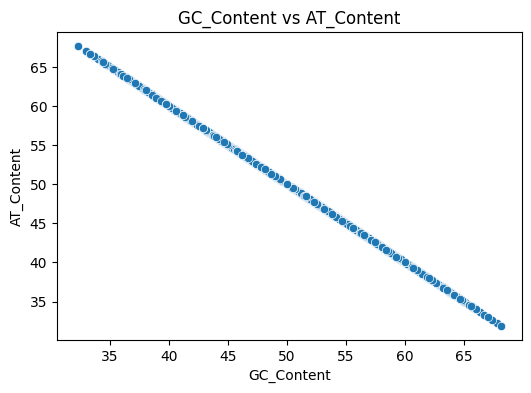

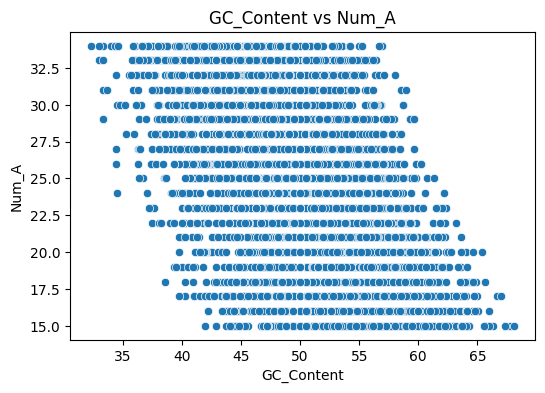

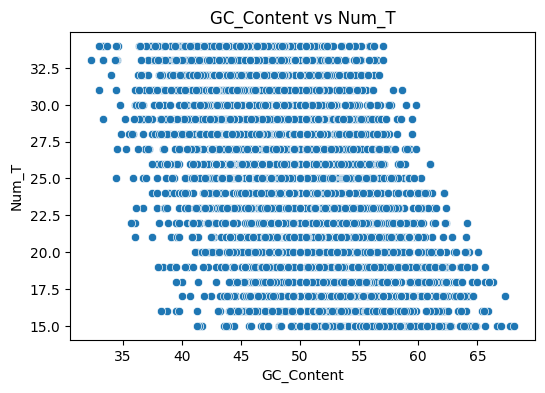

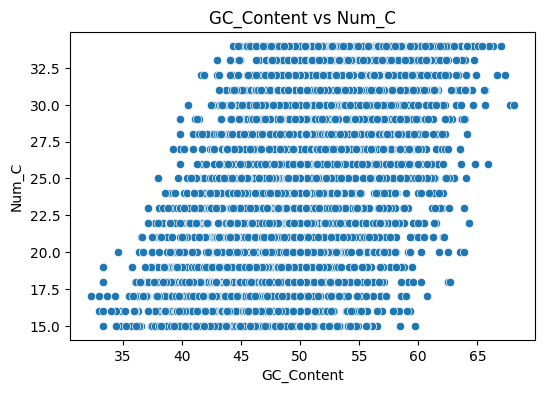

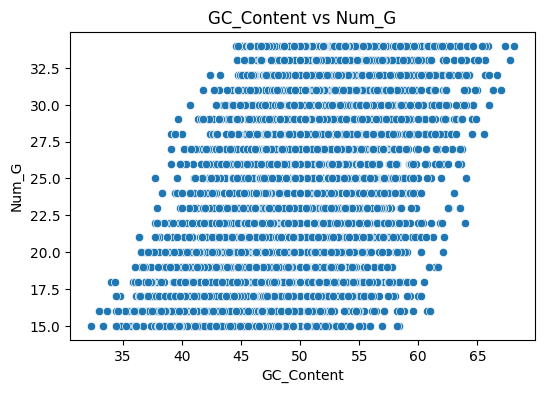

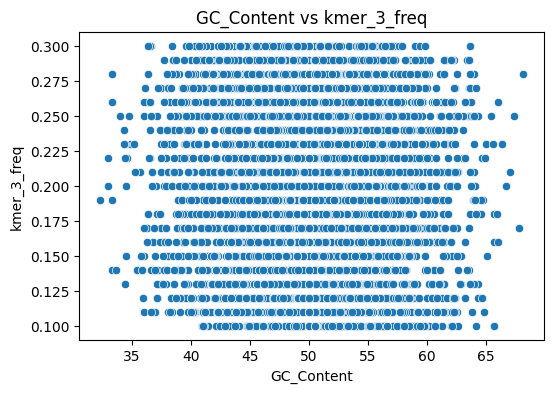

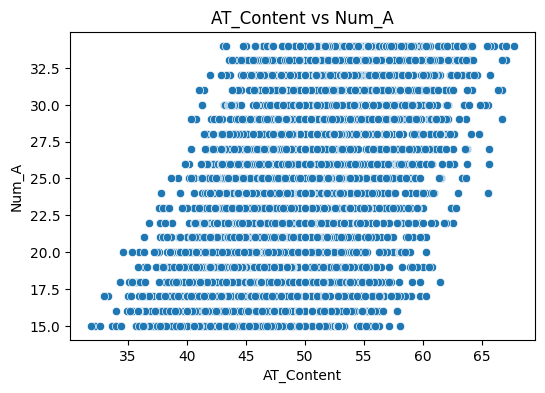

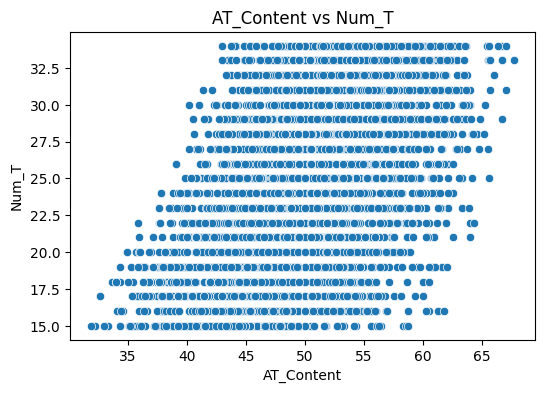

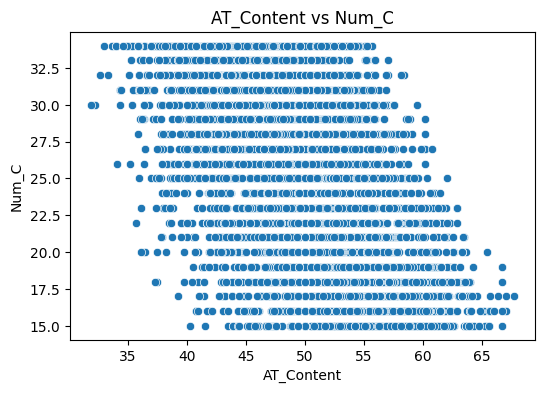

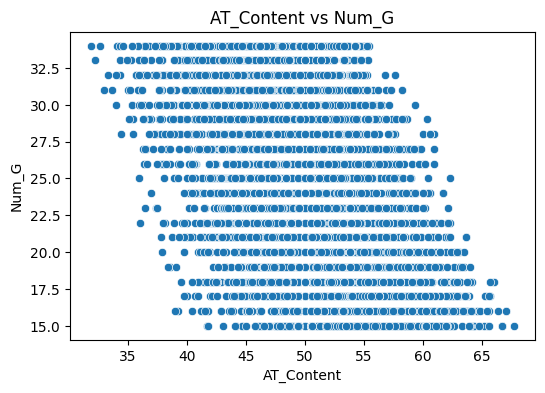

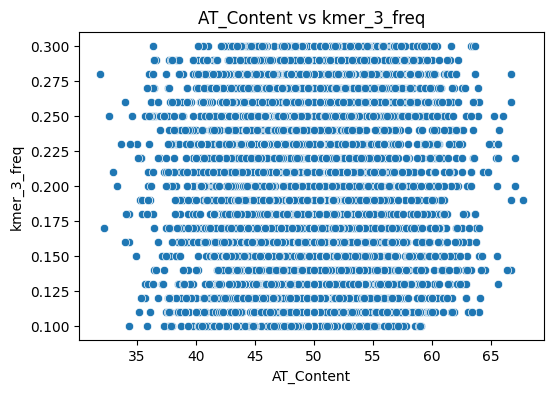

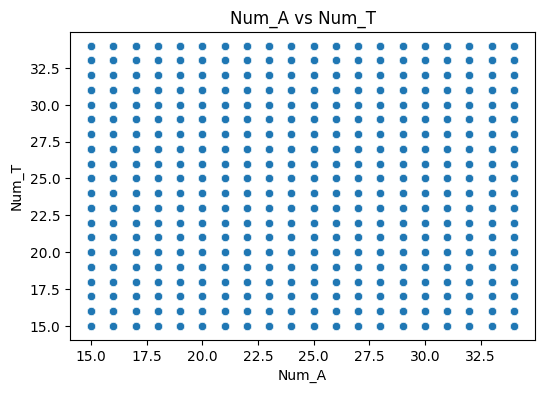

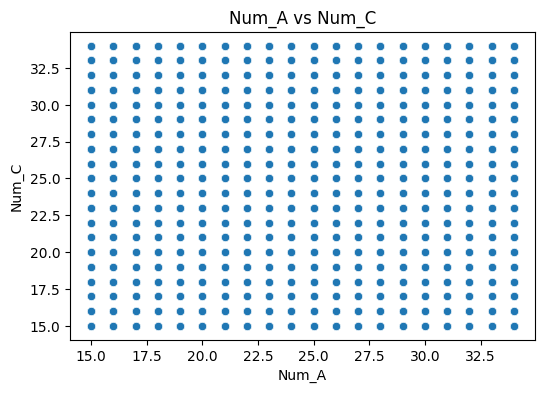

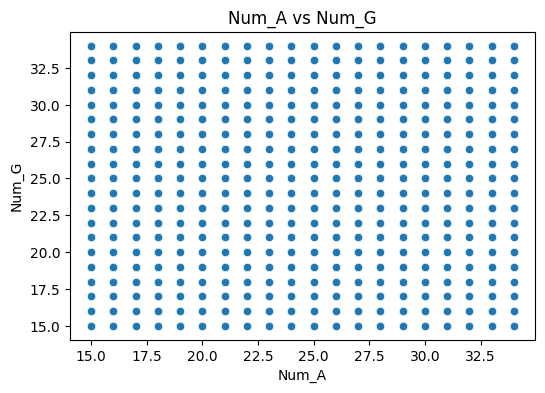

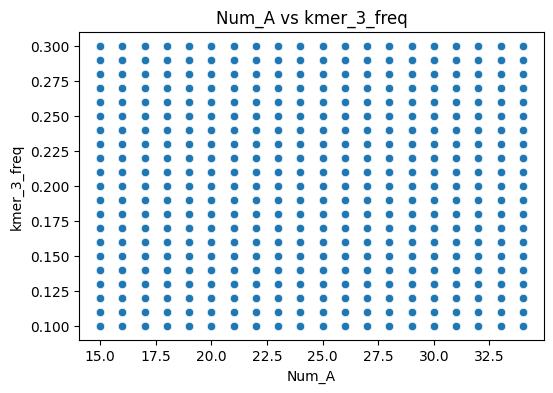

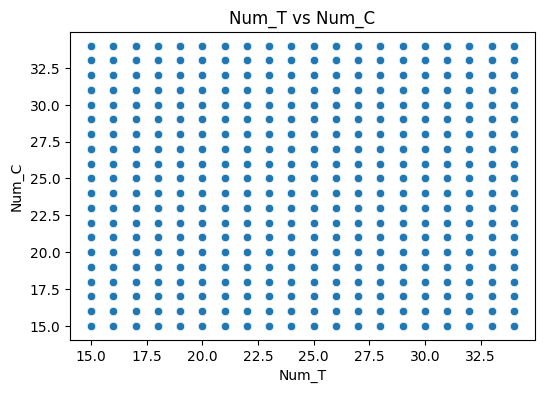

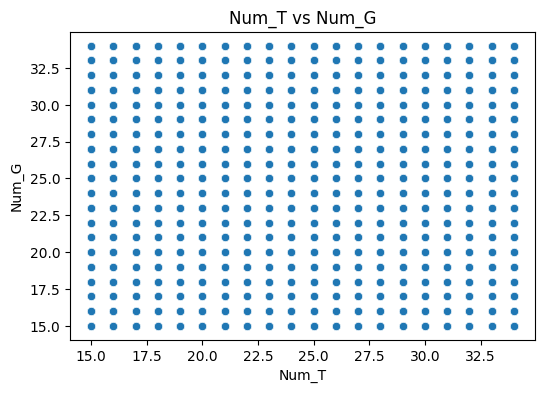

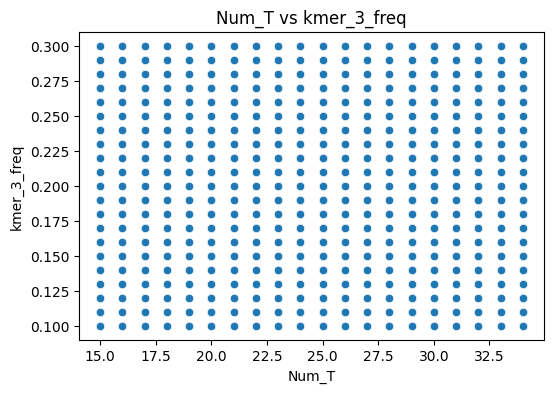

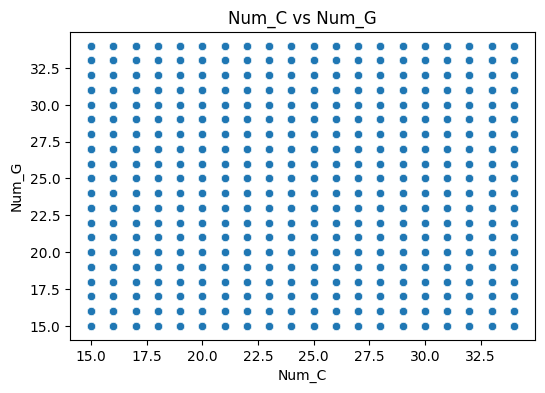

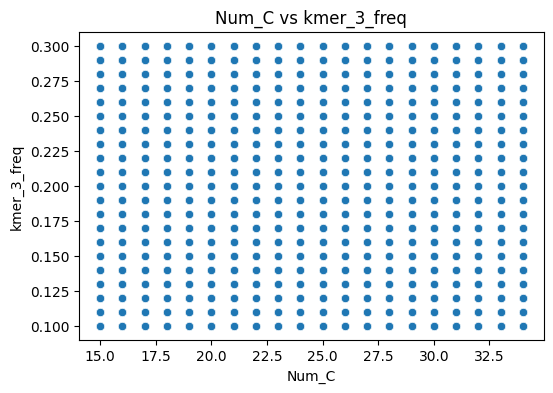

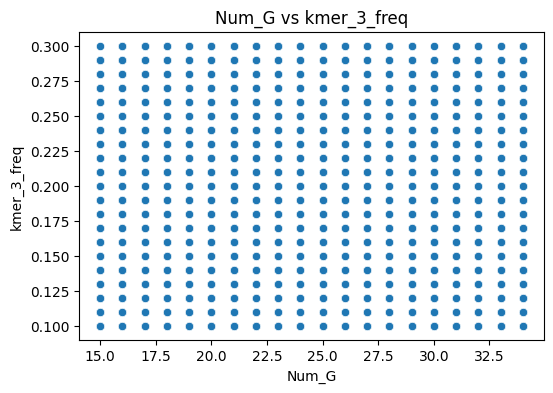

In [ ]:
#STEP 7 ::: BIVARIATE ANALYSIS(EXAMINING THE RELATIONSHIP BETWEEN TWO FEATURES).
import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = [
    'GC_Content',
    'AT_Content',
    'Num_A',
    'Num_T',
    'Num_C',
    'Num_G',
    'kmer_3_freq'
]

for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):

        plt.figure(figsize=(6,4))

        sns.scatterplot(
            x=df[numerical_cols[i]],
            y=df[numerical_cols[j]]
        )

        plt.title(
            f"{numerical_cols[i]} vs {numerical_cols[j]}"
        )

        plt.show()

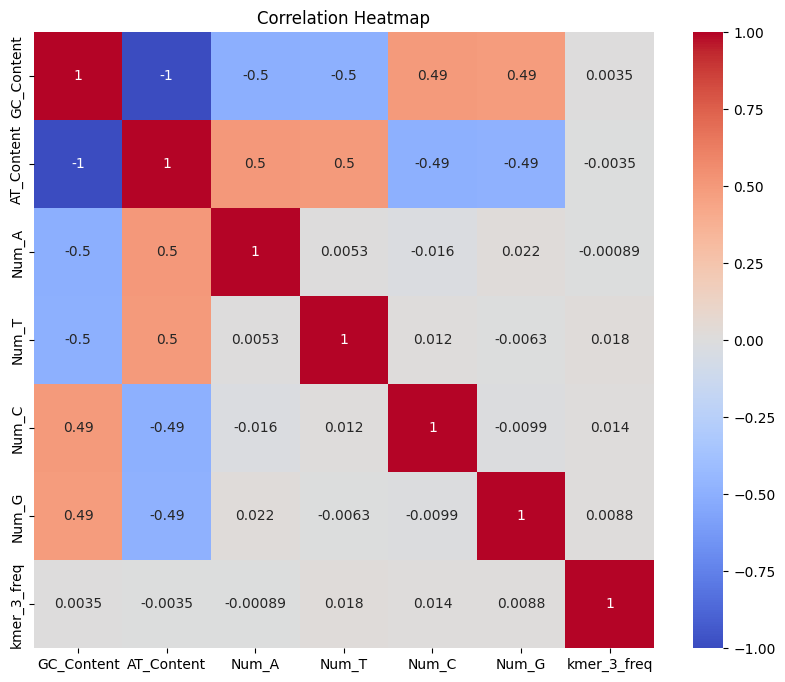

In [10]:
#STEP 8 ::: FIND THE CORRELATION BETWEEN DIFFERENT FEATURES OF THE DATASET AND VISUALIZE THE CORRELATIONS BETWEEN DIFFERENT COLUMNS.
import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = [
    'GC_Content',
    'AT_Content',
    'Num_A',
    'Num_T',
    'Num_C',
    'Num_G',
    'kmer_3_freq'
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [13]:
#RANDOM FOREST CLASSIFIER ::: IT IS A SUPERVISED MACHINE LEARNING ALGORITHM USED FOR BOTH CLASSIFICATION AND REGRESSION PROBLEMS. RANDOM FOREST WORKS BY CREATING MULTIPLE DECISION TREES USING RANDOMLY SELECTED SAMPLES OF THE DATASET. EACH DECISION TREE MAKES ITS OWN PREDICTION AND THE FINAL OUTPUT IS DETERMINED BY MAJORITY VOTING IN CLASSIFICATION PROBLEMS. THIS HELPS REDUCE OVERFITTING, IMPROVES GENERALIZATION, AND PROVIDES MORE ACCURATE AND RELIABLE PREDICTIONS COMPARED TO A SINGLE DECISION TREE. THE ACCURACY_SCORE IS USED TO MEASURE THE OVERALL PERFORMANCE OF THE MODEL, WHILE THE CLASSIFICATION_REPORT PROVIDES IMPORTANT EVALUATION METRICS SUCH AS PRECISION, RECALL, F1-SCORE, AND SUPPORT.

#STEP 1 ::: IMPORT ALL THE REQUIRED LIBRARIES.
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

#STEP 2 ::: LOAD THE DATASET AND PREPARE THE FEATURES AND TARGET VARIABLE.
# FEATURES
X = sdf.drop(
    ['Disease_Risk', 'Possible_Diseases'],
    axis=1
)

# TARGET
y = sdf['Disease_Risk']

#STEP 3 ::: SPLIT THE DATASET INTO TRAINING AND TESTING SETS.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#STEP 4 ::: TRAIN THE RANDOM FOREST CLASSIFIER ON THE TRAINING DATA.
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rfc.fit(X_train, y_train)

#STEP 5 ::: MAKE PREDICTIONS USING THE TEST SET.
y_pred = rfc.predict(X_test)

print(y_pred[:10])

#STEP 6 ::: EVALUATE THE MODEL'S PERFORMANCE USING ACCURACY SCORE, CONFUSION MATRIX, AND CLASSIFICATION REPORT.


accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :", accuracy)


cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)


print(
    classification_report(
        y_test,
        y_pred
    )
)

[0 0 0 0 0 0 0 0 0 0]
Accuracy : 0.565
[[464 113]
 [322 101]]
              precision    recall  f1-score   support

           0       0.59      0.80      0.68       577
           1       0.47      0.24      0.32       423

    accuracy                           0.56      1000
   macro avg       0.53      0.52      0.50      1000
weighted avg       0.54      0.56      0.53      1000

